In [67]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib

In [31]:
path = kagglehub.dataset_download("theaimindset/customer-behavior-and-churn-simulation-dataset")

Using Colab cache for faster access to the 'customer-behavior-and-churn-simulation-dataset' dataset.


In [32]:
dataset = pd.read_csv(f"{path}/synthetic_customer_behavior_and_churn.csv")

In [33]:
pd.set_option('display.max_columns', None)
dataset.head()

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,CUST_000001,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


In [34]:
dataset.describe()

,tenure_months,age,monthly_charges,total_charges,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,last_login_days_ago,churn
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000
mean,17.448467,41.646933,59.046174,978.208528,45.235633,18.519600,2.927133,3.38440,21.748533,0.318867
std,10.304214,11.740994,32.996490,864.474724,29.244734,12.335911,2.609012,1.24951,22.282570,0.466053
min,1.000000,18.000000,19.990000,16.500000,5.000000,1.000000,0.000000,1.00000,0.000000,0.000000
25%,8.000000,33.000000,31.640000,351.145000,21.900000,9.000000,1.000000,3.00000,5.000000,0.000000
50%,17.000000,42.000000,55.150000,735.260000,40.500000,16.000000,2.000000,4.00000,13.000000,0.000000
75%,26.000000,50.000000,73.742500,1372.332500,58.500000,24.000000,4.000000,4.00000,32.000000,1.000000
max,35.000000,80.000000,149.950000,5506.350000,119.900000,49.000000,11.000000,5.00000,89.000000,1.000000


In [35]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   15000 non-null  object 
 1   signup_date                   15000 non-null  object 
 2   tenure_months                 15000 non-null  int64  
 3   age                           15000 non-null  int64  
 4   gender                        15000 non-null  object 
 5   region                        15000 non-null  object 
 6   income_level                  15000 non-null  object 
 7   subscription_type             15000 non-null  object 
 8   monthly_charges               15000 non-null  float64
 9   total_charges                 15000 non-null  float64
 10  usage_frequency               15000 non-null  object 
 11  avg_session_duration_minutes  15000 non-null  float64
 12  number_of_logins_per_month    15000 non-null  int64  
 13  n

In [36]:
dataset.duplicated().sum()

np.int64(0)

In [37]:
numerical_col = dataset.select_dtypes(include=np.number).columns
categorical_col = dataset.select_dtypes(include='object').columns

In [38]:
numerical_col

Index(['tenure_months', 'age', 'monthly_charges', 'total_charges',
       'avg_session_duration_minutes', 'number_of_logins_per_month',
       'number_of_support_tickets', 'satisfaction_score',
       'last_login_days_ago', 'churn'],
      dtype='object')

In [39]:
categorical_col

Index(['customer_id', 'signup_date', 'gender', 'region', 'income_level',
       'subscription_type', 'usage_frequency', 'payment_method',
       'contract_type', 'promotional_response', 'discount_used'],
      dtype='object')

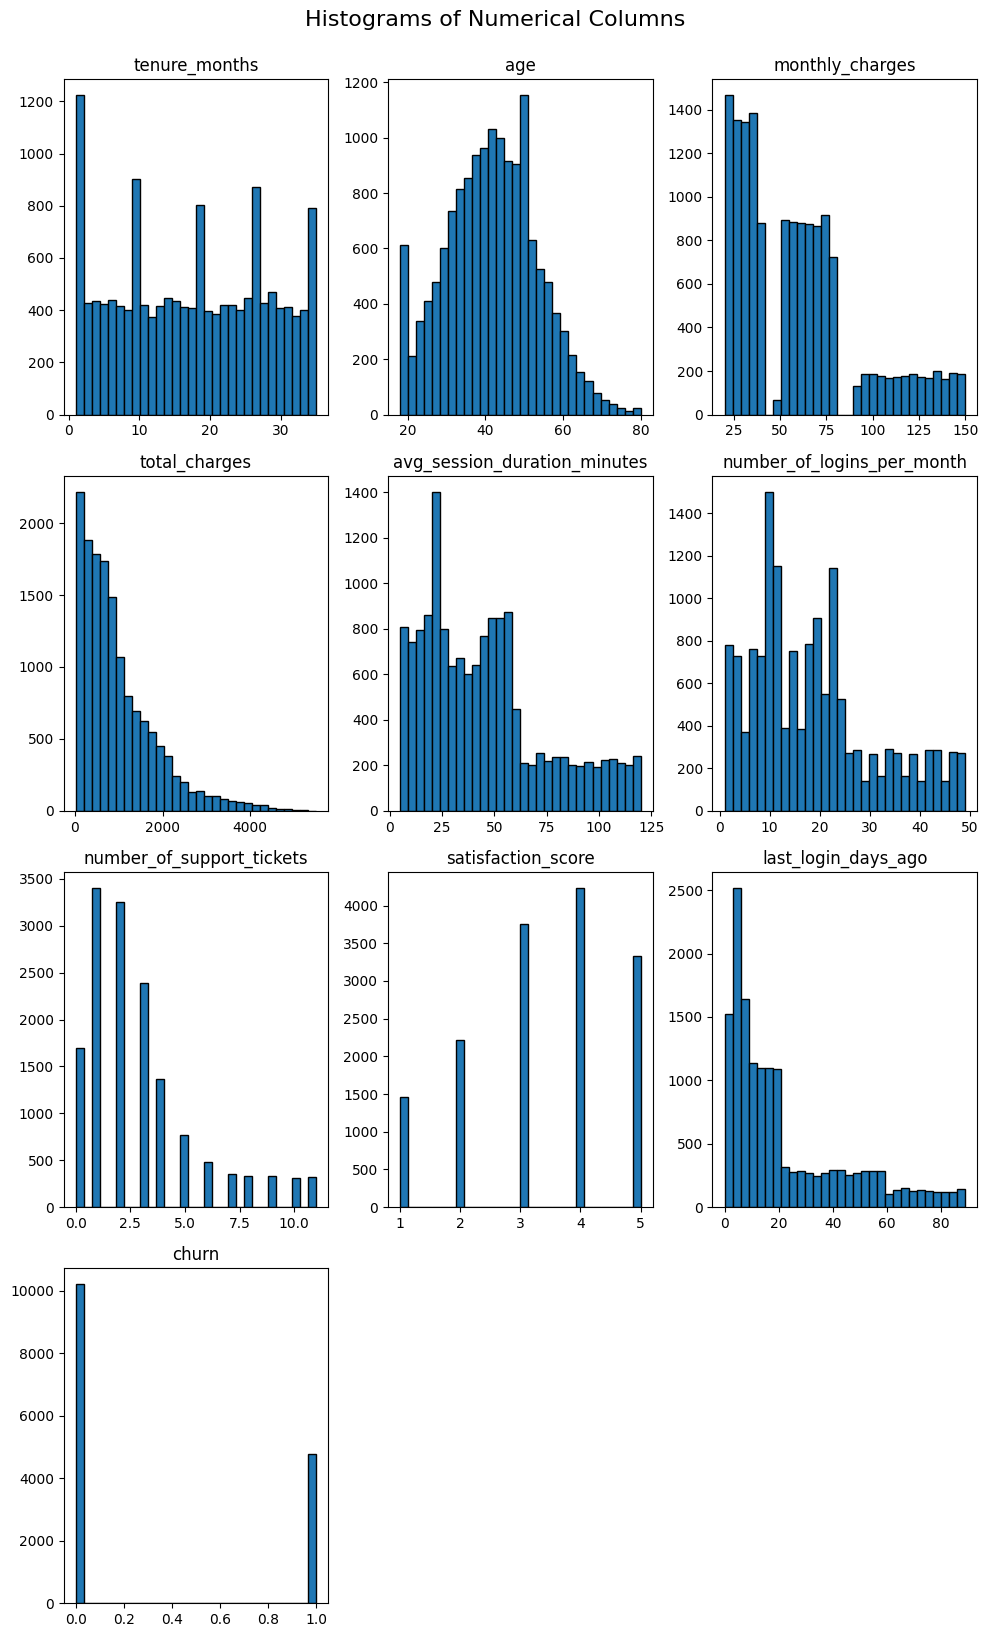

In [40]:
num_cols = len(numerical_col)
num_rows = (num_cols + 2) // 3 # Calculate number of rows needed for 3 columns per row

fig, axs = plt.subplots(num_rows, 3, figsize=(10, num_rows * 4))
axs = axs.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_col):
    if i < len(axs): # Ensure we don't go out of bounds if num_cols < len(axs)
        axs[i].hist(dataset[col], bins=30, edgecolor='k')
        axs[i].set_title(col)
        axs[i].set_xlabel('') # Clear x-axis label from subplots
        axs[i].set_ylabel('') # Clear y-axis label from subplots

# Hide any unused subplots
for j in range(num_cols, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle('Histograms of Numerical Columns', y=1.02, fontsize=16) # Add a main title
plt.show()

In [41]:
for col in numerical_col:
  print(f"Skewness Score of {col}:{dataset[col].skew()}")

Skewness Score of tenure_months:0.019310050069761525
Skewness Score of age:0.1370616821161822
Skewness Score of monthly_charges:0.9920595578597515
Skewness Score of total_charges:1.5474385805446293
Skewness Score of avg_session_duration_minutes:0.804673487382484
Skewness Score of number_of_logins_per_month:0.7549128916362597
Skewness Score of number_of_support_tickets:1.3914186803752306
Skewness Score of satisfaction_score:-0.3709638271592021
Skewness Score of last_login_days_ago:1.2963350403936573
Skewness Score of churn:0.7774118921287697


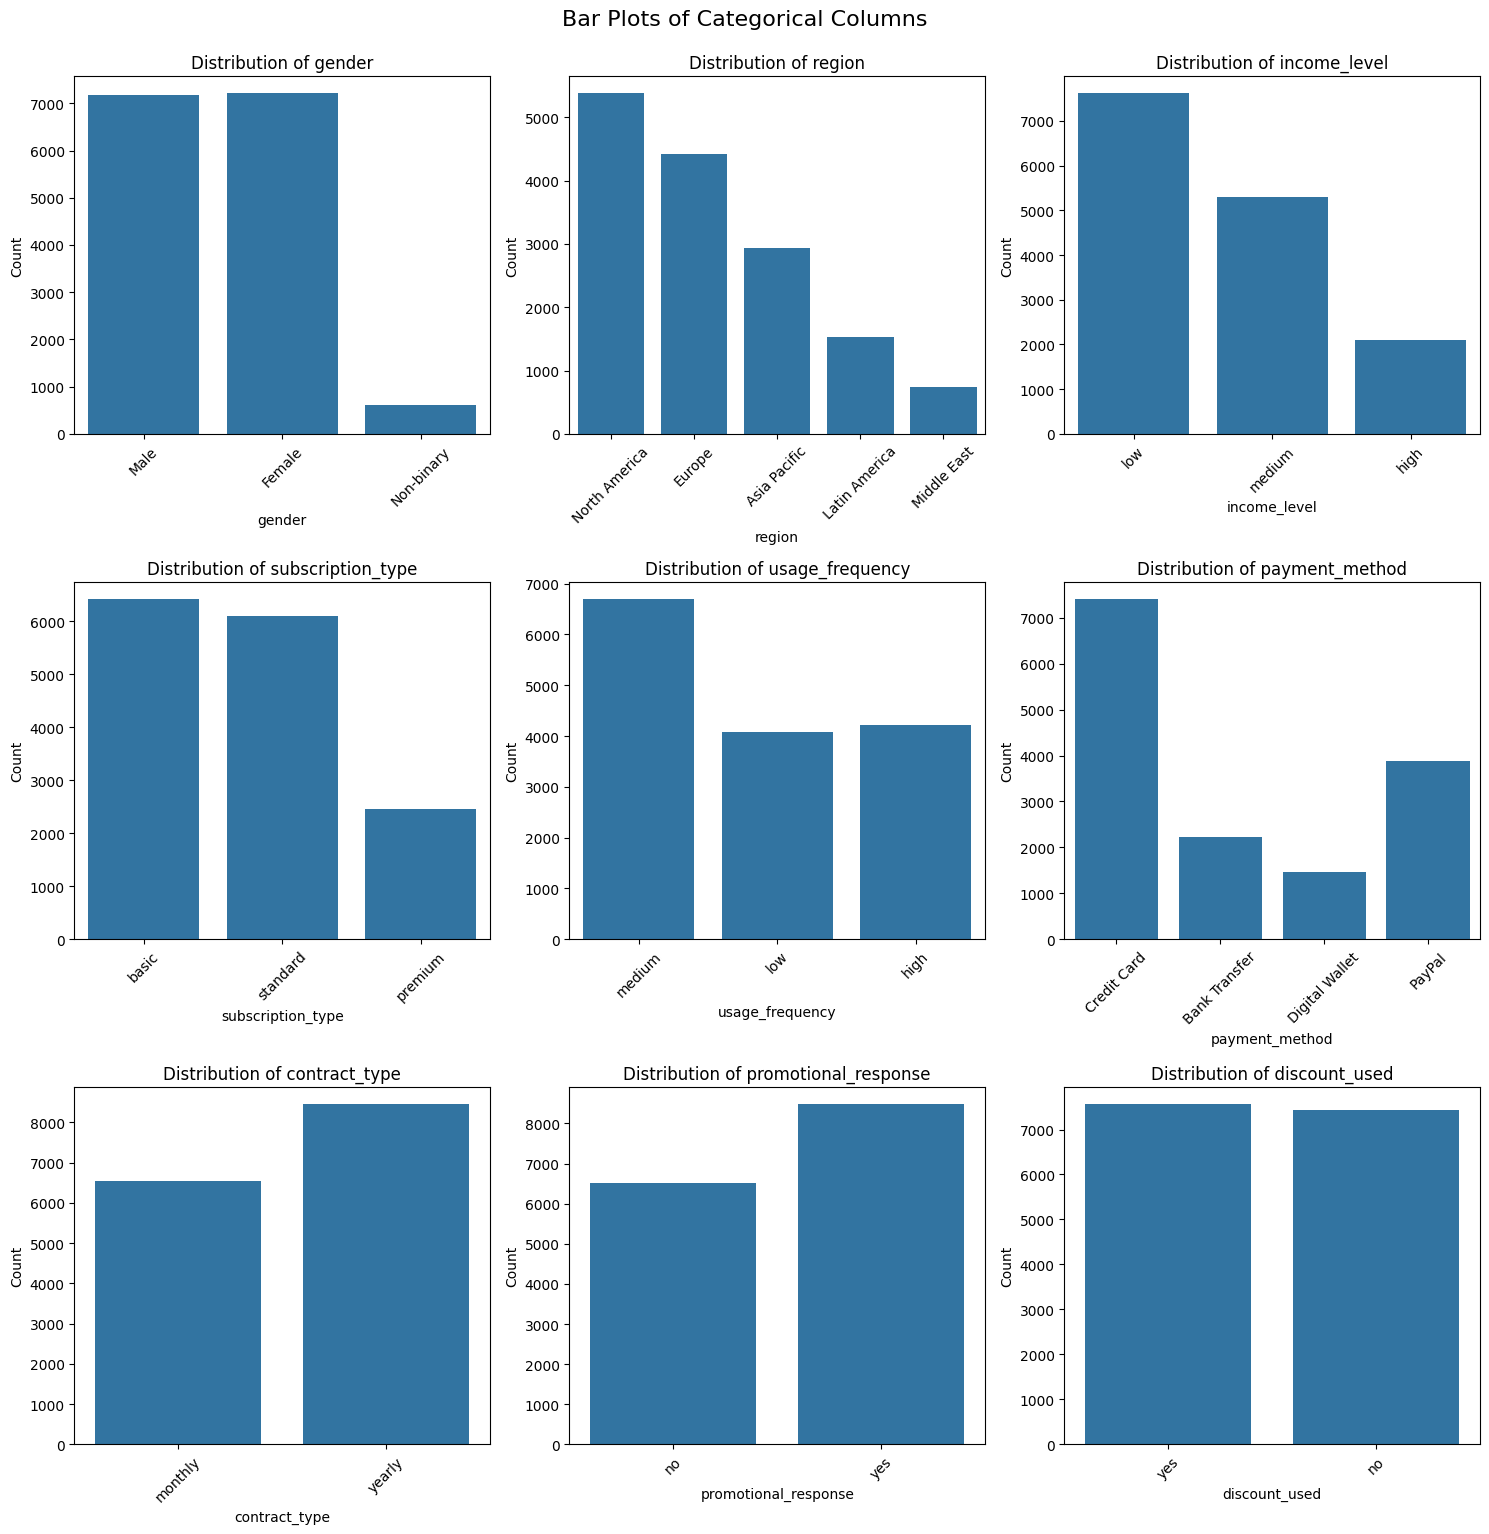

In [42]:
plot_categorical_cols = [col for col in categorical_col if col not in ['customer_id', 'signup_date']]

num_plots = len(plot_categorical_cols)
num_rows = (num_plots + 2) // 3 # Calculate number of rows needed for 3 columns per row
num_cols_per_row = 3

fig, axs = plt.subplots(num_rows, num_cols_per_row, figsize=(15, num_rows * 5))
axs = axs.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(plot_categorical_cols):
    if i < len(axs):
        sns.countplot(data=dataset, x=col, ax=axs[i])
        axs[i].set_title(f'Distribution of {col}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel('Count')
        axs[i].tick_params(axis='x', rotation=45) # Removed 'ha' parameter

# Hide any unused subplots
for j in range(num_plots, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle('Bar Plots of Categorical Columns', y=1.02, fontsize=16)
plt.show()

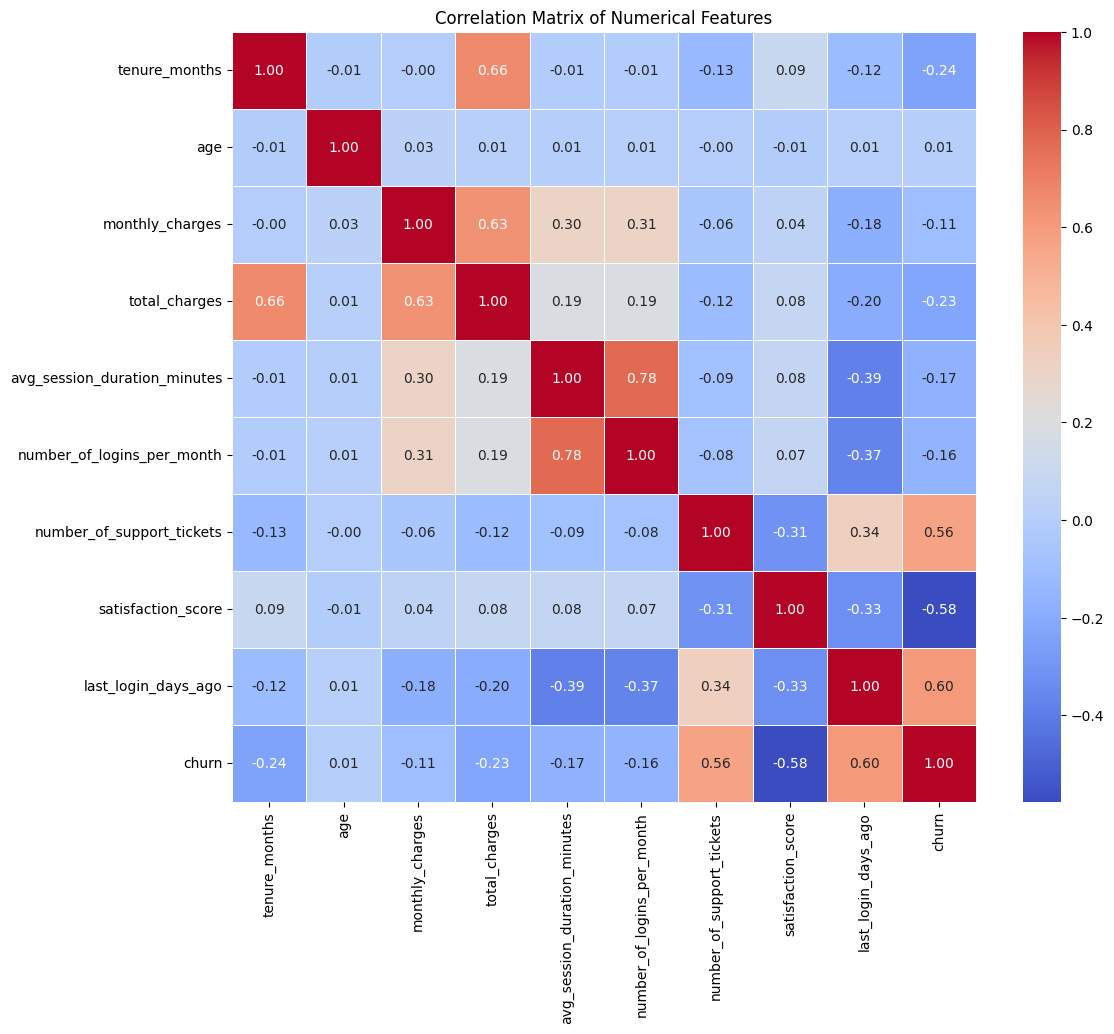

In [43]:
correlation_matrix = dataset[numerical_col].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [44]:
sns.pairplot(dataset[numerical_col], hue='churn', palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Churn Status', y=1.02, fontsize=16)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [45]:
dataset

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,CUST_000001,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,CUST_014996,2024-11-16,1,31,Female,Latin America,low,standard,60.82,53.29,medium,38.7,13,2,3,Credit Card,monthly,67,no,no,1
14996,CUST_014997,2024-10-11,2,56,Female,Latin America,low,basic,34.68,75.17,high,69.1,23,3,2,PayPal,yearly,83,yes,no,1
14997,CUST_014998,2023-07-24,17,57,Female,North America,low,basic,23.80,350.56,medium,31.1,13,2,3,Credit Card,yearly,17,no,no,0
14998,CUST_014999,2023-02-19,22,31,Male,Latin America,medium,standard,67.70,1337.17,medium,38.0,16,1,5,Credit Card,yearly,4,yes,no,0


In [46]:
X = dataset.drop(columns=["churn"])
y = dataset["churn"]

In [47]:
X = X.drop(columns=["customer_id","signup_date"])

In [48]:
X

,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used
0,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,12,1,5,Credit Card,monthly,4,no,yes
1,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,18,1,3,Bank Transfer,yearly,13,no,yes
2,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,8,6,5,Digital Wallet,monthly,54,no,yes
3,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,30,1,3,Credit Card,monthly,6,no,no
4,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,8,3,5,Digital Wallet,yearly,59,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,1,31,Female,Latin America,low,standard,60.82,53.29,medium,38.7,13,2,3,Credit Card,monthly,67,no,no
14996,2,56,Female,Latin America,low,basic,34.68,75.17,high,69.1,23,3,2,PayPal,yearly,83,yes,no
14997,17,57,Female,North America,low,basic,23.80,350.56,medium,31.1,13,2,3,Credit Card,yearly,17,no,no
14998,22,31,Male,Latin America,medium,standard,67.70,1337.17,medium,38.0,16,1,5,Credit Card,yearly,4,yes,no


In [49]:
order = [
    ["low","medium","high"],
    ["basic","standard","premium"],
    ["low","medium","high"],
    ["monthly","yearly"]
]
prepro = ColumnTransformer([
    ("ordinal_encoding",OrdinalEncoder(categories=order),["income_level","subscription_type","usage_frequency","contract_type"]),
    ("onehot_encoding",OneHotEncoder(),["gender","region","payment_method","promotional_response","discount_used"])
    ],remainder="passthrough")

In [50]:
rnf = Pipeline([
    ("preprocessing",prepro),
    ("model",RandomForestClassifier(
    n_estimators=100,           # Number of trees
    max_depth=10,               # Limits how deep/complex each tree gets
    min_samples_split=5,        # Minimum data points needed to make a new branch
    random_state=42,            # Ensures you get the same result every time
    class_weight='balanced'     # CRITICAL for churn (helps with imbalanced data)
))
])

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
rnf.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoding',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high'],
                                                                             ['basic',
                                                                              'standard',
                                                                              'premium'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high'],
                                                                             ['monthly',
                                                                              'yearly']]),
                                                  ['income_level',
                                                   'subscription_type',
                                                   'usage_frequency',
                                                   'contract_type']),
                                                 ('onehot_encoding',
                                                  OneHotEncoder(),
                                                  ['gender', 'region',
                                                   'payment_method',
                                                   'promotional_response',
                                                   'discount_used'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=5,
                                        random_state=42))])

In [53]:
rnf.score(X_test,y_test)

0.9303333333333333

In [54]:
rnf.score(X_train,y_train)

0.959

In [55]:
print(classification_report(y_test,rnf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2045
           1       0.90      0.88      0.89       955

    accuracy                           0.93      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000



In [68]:
model_name = "churn_prediction_v1.joblib"
joblib.dump(rnf,model_name)

['churn_prediction_v1.joblib']

In [56]:
fea_imp = rnf.named_steps["model"].feature_importances_

# Get the feature names after preprocessing
transformed_feature_names = rnf.named_steps["preprocessing"].get_feature_names_out()

importance = pd.Series(fea_imp, index=transformed_feature_names)
importance

,0
ordinal_encoding__income_level,0.003014
ordinal_encoding__subscription_type,0.003588
ordinal_encoding__usage_frequency,0.022054
ordinal_encoding__contract_type,0.049981
onehot_encoding__gender_Female,0.001726
onehot_encoding__gender_Male,0.001860
onehot_encoding__gender_Non-binary,0.001403
onehot_encoding__region_Asia Pacific,0.001509
onehot_encoding__region_Europe,0.001969
onehot_encoding__region_Latin America,0.001618


In [62]:
xgb = Pipeline([
    ("preprocessing",prepro),
    ("model",XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,   # Slow and steady learning
    max_depth=4,          # Very shallow trees to avoid memorizing outliers
    gamma=1,              # Minimum loss reduction to make a split (The "Pruner")
    reg_alpha=0.1,        # L1 regularization (Lasso)
    reg_lambda=1,         # L2 regularization (Ridge)
    scale_pos_weight=2,   # Adjust if your churn class is small
    random_state=42
))
])

In [63]:
xgb.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoding',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high'],
                                                                             ['basic',
                                                                              'standard',
                                                                              'premium'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high'],
                                                                             ['monthly',
                                                                              'yearly']]),
                                                  ['income_level',
                                                   'subscription_type',
                                                   'usage_frequency',
                                                   'contract_type']),
                                                 ('onehot_encoding',
                                                  OneHotEncoder(),
                                                  ['gen...
                               feature_types=None, feature_weights=None,
                               gamma=1, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [64]:
xgb.score(X_test,y_test)

0.9306666666666666

In [65]:
xgb.score(X_train,y_train)

0.9374166666666667

In [66]:
print(classification_report(y_test,xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2045
           1       0.89      0.89      0.89       955

    accuracy                           0.93      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000

